# Customer Segmentation & Retention Analysis  

This notebook is a simplified, teaching-friendly version of the project.

### Models
**Segmentation (Clustering):**
1) **KMeans (baseline)**  
2) **Autoencoder + KMeans (deep learning)**  

**Churn / Retention Risk:**
1) **Logistic Regression (baseline)**  
2) **Random Forest (strong non-linear)**  
3) **HistGradientBoosting (modern boosting)**  

### Required visuals included
- **Correlation heatmap + correlation matrix**
- **ROC curve** (for all churn models)
- **One learning curve for every model**
  - KMeans: inertia “elbow” curve
  - Autoencoder: train vs validation loss curve (+ test loss)
  - Each churn model: learning curve (PR-AUC)

**Dataset expected:** `Online Retail.xlsx` in the same folder.


## Module 0: Setup and Imports

In [ ]:
# If you get missing packages, install them (uncomment):
# !pip install pandas numpy matplotlib scikit-learn openpyxl
# Deep learning autoencoder:
# !pip install torch

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, log_loss
)
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

pd.set_option("display.max_columns", 200)


## Module 1: Load Dataset

In [ ]:
DATA_PATH = "Online Retail.xlsx"
df_raw = pd.read_excel(DATA_PATH)
df_raw.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
print("Shape:", df_raw.shape)
display(df_raw.dtypes)
display(df_raw.isna().mean().sort_values(ascending=False).head(12))


Shape: (541909, 8)


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


,0
CustomerID,0.249267
Description,0.002683
StockCode,0.000000
InvoiceNo,0.000000
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
Country,0.000000


## Module 2: Data Cleaning

We clean the dataset so it represents **real purchases**:
- Drop missing CustomerID
- Remove cancellations (InvoiceNo contains 'C')
- Keep only Quantity > 0 and UnitPrice > 0
- Create TotalPrice = Quantity × UnitPrice


In [ ]:
df = df_raw.copy()
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# raw-ish copy for return/cancel rates
df_flags = df.copy()

df = df.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)

df_flags = df_flags.dropna(subset=["CustomerID"]).copy()
df_flags["CustomerID"] = df_flags["CustomerID"].astype(int).astype(str)
df_flags["is_cancel"] = df_flags["InvoiceNo"].str.startswith("C") | df_flags["InvoiceNo"].str.contains("C", na=False)

is_cancel = df["InvoiceNo"].str.startswith("C") | df["InvoiceNo"].str.contains("C", na=False)
df = df[~is_cancel].copy()

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

quality = {
    "raw_rows": int(len(df_raw)),
    "missing_customerid_rows": int(df_raw["CustomerID"].isna().sum()),
    "final_rows_for_modeling": int(len(df)),
}
display(pd.DataFrame([quality]))
print("Snapshot date:", snapshot_date)


,raw_rows,missing_customerid_rows,final_rows_for_modeling
0,541909,135080,397884


Snapshot date: 2011-12-10 12:50:00


## Module 3: Customer Feature Engineering (RFM + behavior)

In [ ]:
def gap_stats(x_dates: pd.Series):
    x = pd.Series(sorted(pd.to_datetime(x_dates).unique()))
    if len(x) <= 1:
        return pd.Series({"gap_mean_days": np.nan, "gap_std_days": np.nan, "gap_min_days": np.nan, "gap_max_days": np.nan})
    gaps = x.diff().dt.days.dropna()
    return pd.Series({
        "gap_mean_days": float(gaps.mean()),
        "gap_std_days": float(gaps.std(ddof=0)),
        "gap_min_days": float(gaps.min()),
        "gap_max_days": float(gaps.max()),
    })

cust_core = df.groupby("CustomerID").agg(
    first_purchase=("InvoiceDate", "min"),
    last_purchase=("InvoiceDate", "max"),
    frequency=("InvoiceNo", "nunique"),
    monetary=("TotalPrice", "sum"),
    total_qty=("Quantity", "sum"),
    unique_products=("StockCode", "nunique"),
).reset_index()

cust_core["tenure_days"] = (cust_core["last_purchase"] - cust_core["first_purchase"]).dt.days.clip(lower=0)
cust_core["recency_days"] = (snapshot_date - cust_core["last_purchase"]).dt.days
cust_core["avg_order_value"] = cust_core["monetary"] / cust_core["frequency"].replace(0, np.nan)
cust_core["basket_size"] = cust_core["total_qty"] / cust_core["frequency"].replace(0, np.nan)

cust_gaps = df.groupby("CustomerID")["InvoiceDate"].apply(gap_stats).unstack() # Modified line
cust = cust_core.merge(cust_gaps, on="CustomerID", how="left")

flags = df_flags.copy()
flags["is_return"] = flags["Quantity"] < 0
ret = flags.groupby("CustomerID").agg(
    return_rows=("is_return", "sum"),
    cancel_rows=("is_cancel", "sum"),
    total_rows=("InvoiceNo", "count"),
).reset_index()

cust = cust.merge(ret, on="CustomerID", how="left")
cust[["return_rows","cancel_rows","total_rows"]] = cust[["return_rows","cancel_rows","total_rows"]].fillna(0)
cust["return_rate"] = cust["return_rows"] / cust["total_rows"].replace(0, np.nan)
cust["cancel_rate"] = cust["cancel_rows"] / cust["total_rows"].replace(0, np.nan)

display(cust.head())
print("Customers:", cust.shape[0])

,CustomerID,first_purchase,last_purchase,frequency,monetary,total_qty,unique_products,tenure_days,recency_days,avg_order_value,basket_size,gap_mean_days,gap_std_days,gap_min_days,gap_max_days,return_rows,cancel_rows,total_rows,return_rate,cancel_rate
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,1,0,326,77183.600000,74215.000000,NaN,NaN,NaN,NaN,1,1,2,0.5,0.5
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,2458,103,365,2,615.714286,351.142857,60.333333,16.868775,37.0,90.0,0,0,182,0.0,0.0
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,2341,22,282,75,449.310000,585.250000,94.000000,57.277104,39.0,173.0,0,0,31,0.0,0.0
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,73,0,19,1757.550000,631.000000,NaN,NaN,NaN,NaN,0,0,73,0.0,0.0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,17,0,310,334.400000,197.000000,NaN,NaN,NaN,NaN,0,0,17,0.0,0.0


Customers: 4338


## Module 4: Correlation Matrix + Heatmap (Spearman)

,recency_days,frequency,monetary,avg_order_value,basket_size,unique_products,tenure_days,gap_mean_days,gap_std_days,gap_min_days,gap_max_days,return_rate,cancel_rate
recency_days,1.000,-0.562,-0.482,-0.126,-0.162,-0.458,-0.561,0.180,-0.210,0.255,-0.004,-0.181,-0.181
frequency,-0.562,1.000,0.807,0.155,0.139,0.657,0.893,-0.444,0.563,-0.670,-0.106,0.381,0.381
monetary,-0.482,0.807,1.000,0.675,0.561,0.726,0.723,-0.337,0.371,-0.487,-0.099,0.394,0.394
avg_order_value,-0.126,0.155,0.675,1.000,0.807,0.412,0.145,-0.042,0.072,-0.073,-0.017,0.202,0.202
basket_size,-0.162,0.139,0.561,0.807,1.000,0.427,0.130,-0.024,0.062,-0.045,-0.005,0.137,0.137
unique_products,-0.458,0.657,0.726,0.412,0.427,1.000,0.602,-0.215,0.309,-0.364,-0.024,0.228,0.228
tenure_days,-0.561,0.893,0.723,0.145,0.130,0.602,1.000,0.238,0.516,-0.142,0.513,0.335,0.335
gap_mean_days,0.180,-0.444,-0.337,-0.042,-0.024,-0.215,0.238,1.000,0.085,0.735,0.860,-0.135,-0.135
gap_std_days,-0.210,0.563,0.371,0.072,0.062,0.309,0.516,0.085,1.000,-0.451,0.428,0.154,0.154
gap_min_days,0.255,-0.670,-0.487,-0.073,-0.045,-0.364,-0.142,0.735,-0.451,1.000,0.394,-0.225,-0.225


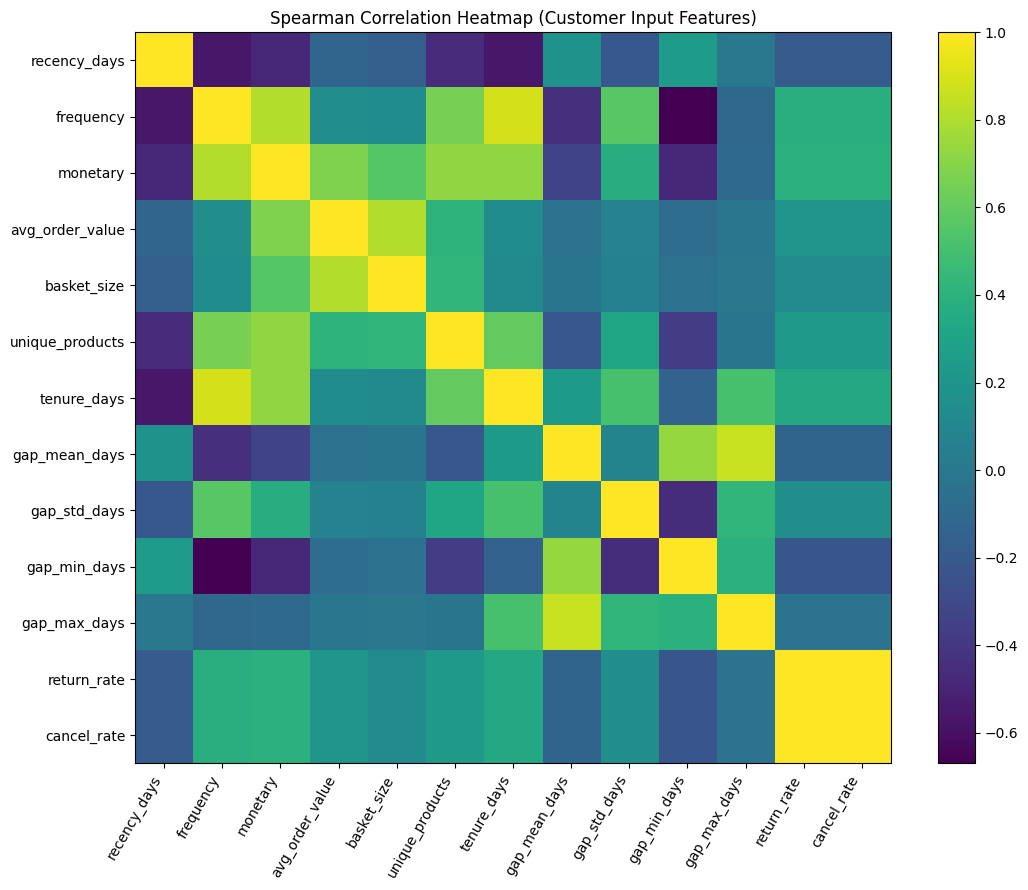

In [ ]:
model_features = [
    "recency_days","frequency","monetary","avg_order_value","basket_size","unique_products",
    "tenure_days","gap_mean_days","gap_std_days","gap_min_days","gap_max_days",
    "return_rate","cancel_rate"
]

corr = cust[model_features].corr(method="spearman").round(3)
display(corr)

plt.figure(figsize=(11, 9))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(model_features)), model_features, rotation=60, ha="right")
plt.yticks(range(len(model_features)), model_features)
plt.title("Spearman Correlation Heatmap (Customer Input Features)")
plt.colorbar()
plt.tight_layout()
plt.show()


## Module 5: Preprocessing (log1p + RobustScaler)

In [ ]:
X = cust[model_features].copy()

gap_cols = ["gap_mean_days","gap_std_days","gap_min_days","gap_max_days"]
X[gap_cols] = X[gap_cols].fillna(0)
X[["return_rate","cancel_rate"]] = X[["return_rate","cancel_rate"]].fillna(0)

log_cols = [
    "recency_days","frequency","monetary","avg_order_value","basket_size","unique_products",
    "tenure_days","gap_mean_days","gap_std_days","gap_min_days","gap_max_days"
]
X_log = X.copy()
for c in log_cols:
    X_log[c] = np.log1p(X_log[c].clip(lower=0))

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

print("X_scaled shape:", X_scaled.shape)


X_scaled shape: (4338, 13)


## Module 6: Segmentation Model 1 — KMeans (Baseline) + Elbow Curve

,k,silhouette,davies_bouldin,calinski_harabasz,method
0,2,0.789531,0.574572,4816.498595,KMeans_raw
1,3,0.591241,0.674982,5008.801548,KMeans_raw
4,6,0.309970,0.950293,4283.946596,KMeans_raw
3,5,0.309471,0.938008,4494.512647,KMeans_raw
2,4,0.297852,0.992429,4481.642101,KMeans_raw
5,7,0.270912,1.064867,4053.432288,KMeans_raw
7,9,0.261893,0.991180,3841.466334,KMeans_raw
6,8,0.261893,1.038464,3892.890363,KMeans_raw
8,10,0.256854,1.035297,3734.330469,KMeans_raw


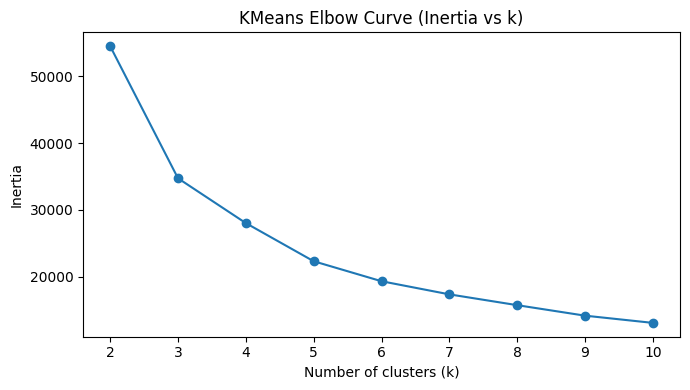

Best k for KMeans (raw features): 2


In [ ]:
def cluster_metrics(Xs, labels):
    k = len(np.unique(labels))
    if k <= 1:
        return {"k": k, "silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    return {
        "k": k,
        "silhouette": float(silhouette_score(Xs, labels)),
        "davies_bouldin": float(davies_bouldin_score(Xs, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(Xs, labels)),
    }

k_list = range(2, 11)

rows = []
inertias = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    r = cluster_metrics(X_scaled, labels)
    r.update({"method":"KMeans_raw","k":k})
    rows.append(r)

kmeans_raw_results = pd.DataFrame(rows).sort_values(["silhouette","calinski_harabasz"], ascending=[False, False])
display(kmeans_raw_results.head(10))

plt.figure(figsize=(7,4))
plt.plot(list(k_list), inertias, marker="o")
plt.title("KMeans Elbow Curve (Inertia vs k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

best_k_raw = int(kmeans_raw_results.iloc[0]["k"])
print("Best k for KMeans (raw features):", best_k_raw)


## Module 7: Segmentation Model 2 — Autoencoder + KMeans (Deep Learning)

Device: cpu
Epoch 01/25  train_loss=2.320838  val_loss=1.961692
Epoch 05/25  train_loss=1.733976  val_loss=1.324053
Epoch 10/25  train_loss=0.327814  val_loss=0.332924
Epoch 15/25  train_loss=0.213191  val_loss=0.215851
Epoch 20/25  train_loss=0.176022  val_loss=0.182695
Epoch 25/25  train_loss=0.150662  val_loss=0.155370
Final TEST loss (MSE): 0.159746


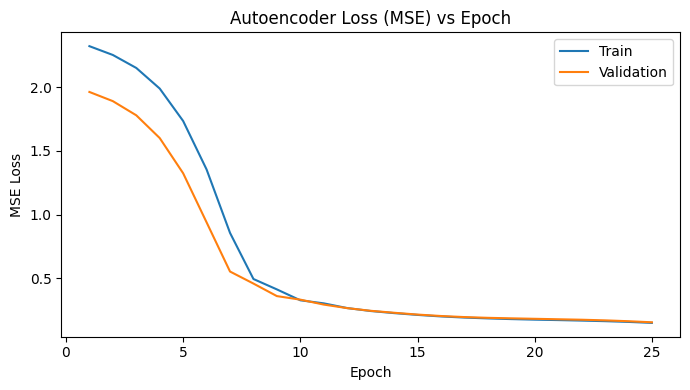

Embedding shape: (4338, 6)


In [ ]:
# If this fails, install:  !pip install torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

X_train_ae, X_temp_ae = train_test_split(X_scaled, test_size=0.30, random_state=42)
X_val_ae, X_test_ae  = train_test_split(X_temp_ae, test_size=0.50, random_state=42)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_ae, dtype=torch.float32)), batch_size=512, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val_ae, dtype=torch.float32)), batch_size=512, shuffle=False)
test_tensor  = torch.tensor(X_test_ae, dtype=torch.float32).to(device)

ae = AutoEncoder(input_dim=X_scaled.shape[1], latent_dim=6).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

train_loss_history, val_loss_history = [], []
epochs = 25

for ep in range(1, epochs+1):
    ae.train()
    train_tot = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        opt.zero_grad()
        recon, _ = ae(xb)
        loss = loss_fn(recon, xb)
        loss.backward()
        opt.step()
        train_tot += loss.item() * xb.size(0)
    train_loss = train_tot / len(X_train_ae)
    train_loss_history.append(train_loss)

    ae.eval()
    val_tot = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb = xb.to(device)
            recon, _ = ae(xb)
            val_tot += loss_fn(recon, xb).item() * xb.size(0)
    val_loss = val_tot / len(X_val_ae)
    val_loss_history.append(val_loss)

    if ep % 5 == 0 or ep == 1:
        print(f"Epoch {ep:02d}/{epochs}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}")

ae.eval()
with torch.no_grad():
    recon, _ = ae(test_tensor)
    test_loss = loss_fn(recon, test_tensor).item()
print("Final TEST loss (MSE):", round(test_loss, 6))

plt.figure(figsize=(7,4))
plt.plot(range(1, len(train_loss_history)+1), train_loss_history, label="Train")
plt.plot(range(1, len(val_loss_history)+1), val_loss_history, label="Validation")
plt.title("Autoencoder Loss (MSE) vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

ae.eval()
with torch.no_grad():
    _, Z = ae(torch.tensor(X_scaled, dtype=torch.float32).to(device))
Z = Z.cpu().numpy()
print("Embedding shape:", Z.shape)


### Module 7.1: KMeans on embeddings + compare with baseline

,k,silhouette,davies_bouldin,calinski_harabasz,method
0,2,0.816249,0.528328,5487.950684,KMeans_AE
1,3,0.659767,0.561981,6325.363281,KMeans_AE
4,6,0.481665,0.624513,8186.847656,KMeans_AE
3,5,0.481440,0.621880,7642.660156,KMeans_AE
2,4,0.455632,0.663431,6728.093750,KMeans_AE
7,9,0.424277,0.641253,9343.527344,KMeans_AE
5,7,0.424154,0.668075,8319.803711,KMeans_AE
6,8,0.423725,0.641646,8797.848633,KMeans_AE
8,10,0.384716,0.694112,9530.539062,KMeans_AE


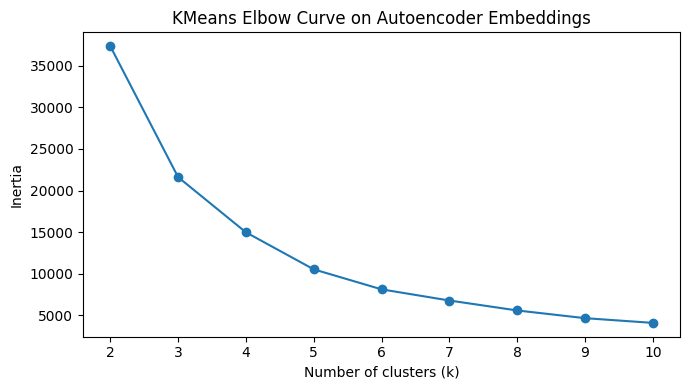

Best k for KMeans (AE embeddings): 2


,method,k,silhouette,davies_bouldin,calinski_harabasz
0,KMeans_raw,2,0.789531,0.574572,4816.498595
1,KMeans_AE,2,0.816249,0.528328,5487.950684


Final segmentation choice: AE+KMeans


In [ ]:
rows = []
inertias_emb = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Z)
    inertias_emb.append(km.inertia_)
    r = cluster_metrics(Z, labels)
    r.update({"method":"KMeans_AE","k":k})
    rows.append(r)

kmeans_ae_results = pd.DataFrame(rows).sort_values(["silhouette","calinski_harabasz"], ascending=[False, False])
display(kmeans_ae_results.head(10))

plt.figure(figsize=(7,4))
plt.plot(list(k_list), inertias_emb, marker="o")
plt.title("KMeans Elbow Curve on Autoencoder Embeddings")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

best_k_ae = int(kmeans_ae_results.iloc[0]["k"])
print("Best k for KMeans (AE embeddings):", best_k_ae)

best_raw = kmeans_raw_results.iloc[0]
best_ae = kmeans_ae_results.iloc[0]
comp = pd.DataFrame([
    {"method":"KMeans_raw", **best_raw.to_dict()},
    {"method":"AE+KMeans", **best_ae.to_dict()},
])[["method","k","silhouette","davies_bouldin","calinski_harabasz"]]
display(comp)

use_ae = best_ae["silhouette"] >= best_raw["silhouette"]
print("Final segmentation choice:", "AE+KMeans" if use_ae else "KMeans_raw")


## Module 8: Final Segments + Segment Profile

In [ ]:
if use_ae:
    final_k = best_k_ae
    final_model = KMeans(n_clusters=final_k, n_init=10, random_state=42)
    cust["segment_id"] = final_model.fit_predict(Z)
else:
    final_k = best_k_raw
    final_model = KMeans(n_clusters=final_k, n_init=10, random_state=42)
    cust["segment_id"] = final_model.fit_predict(X_scaled)

segment_profile = cust.groupby("segment_id").agg(
    customers=("CustomerID","nunique"),
    monetary_total=("monetary","sum"),
    monetary_mean=("monetary","mean"),
    frequency_mean=("frequency","mean"),
    recency_mean=("recency_days","mean"),
).reset_index()

segment_profile["revenue_share"] = segment_profile["monetary_total"] / segment_profile["monetary_total"].sum()
display(segment_profile.sort_values("monetary_total", ascending=False))


,segment_id,customers,monetary_total,monetary_mean,frequency_mean,recency_mean,revenue_share
0,0,4178,8299159.634,1986.395317,4.303494,91.079464,0.931296
1,1,160,612248.270,3826.551688,3.450000,130.581250,0.068704


## Module 9: Retention Analysis (Cohorts)

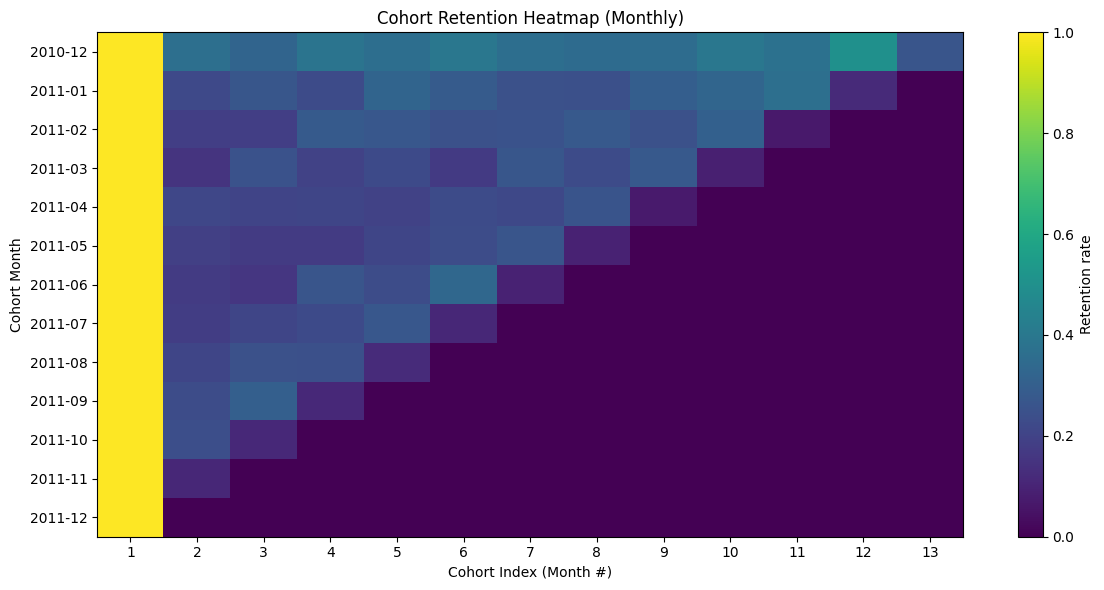

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,0.000000
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,0.000000,0.000000
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,0.000000,0.000000,0.000000
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_c = df.copy()
df_c["InvoiceMonth"] = df_c["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

first_month = df_c.groupby("CustomerID")["InvoiceMonth"].min().rename("CohortMonth")
df_c = df_c.join(first_month, on="CustomerID")

def month_diff(a, b):
    return (a.year - b.year) * 12 + (a.month - b.month)

df_c["CohortIndex"] = df_c.apply(lambda r: month_diff(r["InvoiceMonth"], r["CohortMonth"]) + 1, axis=1)

cohort_data = df_c.groupby(["CohortMonth","CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID").fillna(0)
retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)

plt.figure(figsize=(12,6))
plt.imshow(retention.values, aspect="auto")
plt.title("Cohort Retention Heatmap (Monthly)")
plt.xlabel("Cohort Index (Month #)")
plt.ylabel("Cohort Month")
plt.xticks(range(retention.shape[1]), retention.columns)
plt.yticks(range(retention.shape[0]), retention.index.strftime("%Y-%m"))
plt.colorbar(label="Retention rate")
plt.tight_layout()
plt.show()

display(retention.head())


## Module 10: Churn Prediction (3 models) + metrics table

In [ ]:
CHURN_DAYS = 90
cust["churned"] = (cust["recency_days"] > CHURN_DAYS).astype(int)
display(cust["churned"].value_counts(normalize=True).rename("class_ratio"))


,class_ratio
churned,
0,0.665975
1,0.334025


In [ ]:
X_ml = X_log.copy()
X_ml_scaled = scaler.fit_transform(X_ml)
y = cust["churned"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_ml_scaled, y, test_size=0.2, random_state=42, stratify=y
)

def lift_at_k(y_true, y_prob, k=0.1):
    n = len(y_true)
    top_n = max(1, int(n*k))
    idx = np.argsort(-y_prob)[:top_n]
    captured = y_true[idx].sum()
    base = y_true.sum() * (top_n / n)
    return float(captured / (base + 1e-9))

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced_subsample", n_jobs=-1),
    "HistGB": HistGradientBoostingClassifier(random_state=42),
}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]
    pred = (prob >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": float(accuracy_score(y_test, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, pred)),
        "precision": float(precision_score(y_test, pred, zero_division=0)),
        "recall": float(recall_score(y_test, pred, zero_division=0)),
        "f1": float(f1_score(y_test, pred)),
        "roc_auc": float(roc_auc_score(y_test, prob)),
        "pr_auc": float(average_precision_score(y_test, prob)),
        "lift@10%": float(lift_at_k(y_test, prob, 0.10)),
        "log_loss": float(log_loss(y_test, prob)),
        "prob": prob,
    }

rows = []
cache = {}
for name, m in models.items():
    r = evaluate_model(name, m)
    cache[name] = r
    rows.append({k:v for k,v in r.items() if k != "prob"})

score_df = pd.DataFrame(rows).sort_values(["pr_auc","lift@10%"], ascending=False).reset_index(drop=True)
display(score_df)

best_model_name = score_df.iloc[0]["model"]
print("Best model by PR-AUC then Lift@10%:", best_model_name)


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,lift@10%,log_loss
0,RandomForest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.993103,0.019323
1,HistGB,0.998848,0.998276,1.000000,0.996552,0.998273,1.000000,1.000000,2.993103,0.004026
2,LogReg,0.990783,0.992220,0.976351,0.996552,0.986348,0.999934,0.999871,2.993103,0.054376


Best model by PR-AUC then Lift@10%: RandomForest


### Module 10.1: ROC Curves (All churn models)

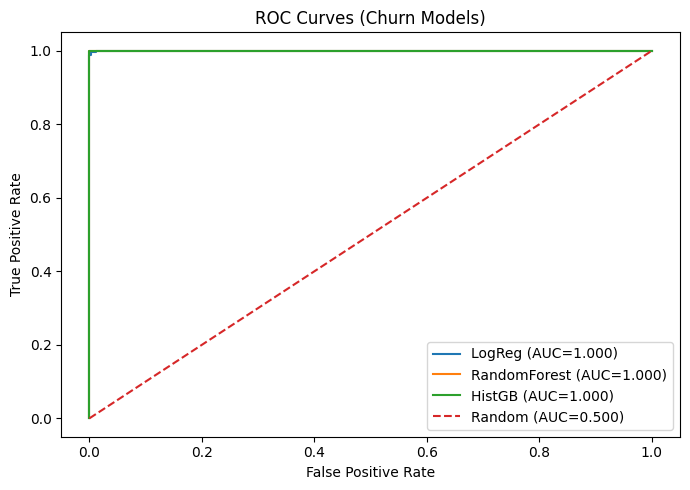

In [ ]:
roc_data = []
for name in models.keys():
    prob = cache[name]["prob"]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    roc_data.append((name, fpr, tpr, auc))

plt.figure(figsize=(7,5))
for name, fpr, tpr, auc in roc_data:
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Random (AUC=0.500)")
plt.title("ROC Curves (Churn Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


### Module 10.2: One Learning Curve for Every Churn Model (PR-AUC)

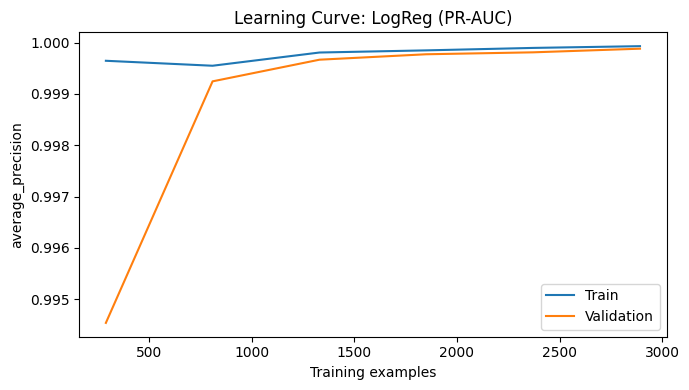

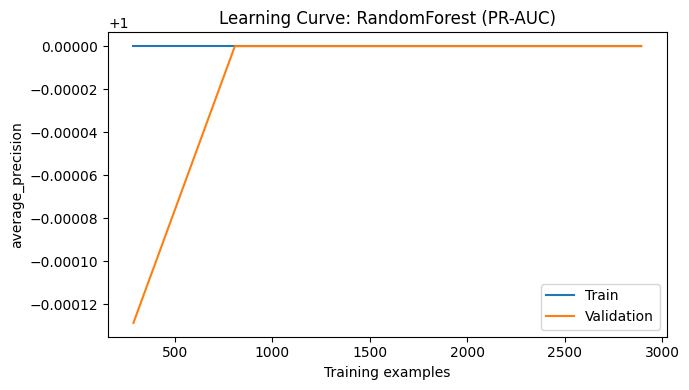

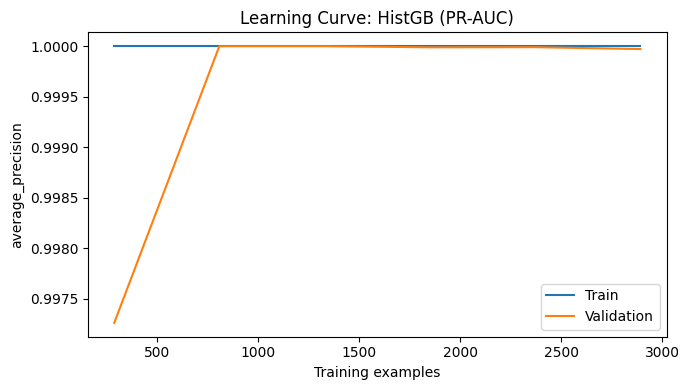

In [ ]:
def plot_learning_curve_one(estimator, X, y, title, scoring="average_precision", cv=3):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X, y,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(7,4))
    plt.plot(train_sizes, train_mean, label="Train")
    plt.plot(train_sizes, val_mean, label="Validation")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend()
    plt.tight_layout()
    plt.show()

for name, m in models.items():
    plot_learning_curve_one(m, X_ml_scaled, y, f"Learning Curve: {name} (PR-AUC)", scoring="average_precision", cv=3)


## Module 11: Hyperparameter tuning (RandomForest only)

In [ ]:
from scipy.stats import randint

rf = RandomForestClassifier(random_state=42, class_weight="balanced_subsample", n_jobs=-1)

param_dist = {
    "n_estimators": randint(200, 1000),
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["sqrt", "log2", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=42
)
rs.fit(X_train, y_train)

rf_tuned = rs.best_estimator_
print("Best PR-AUC (CV):", round(rs.best_score_, 4))
print("Best params:", rs.best_params_)

# Compare tuned vs base on test set
rf_base = models["RandomForest"]

def eval_on_test(model, name):
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]
    pred = (prob >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": float(accuracy_score(y_test, pred)),
        "f1": float(f1_score(y_test, pred)),
        "roc_auc": float(roc_auc_score(y_test, prob)),
        "pr_auc": float(average_precision_score(y_test, prob)),
        "lift@10%": float(lift_at_k(y_test, prob, 0.10)),
        "log_loss": float(log_loss(y_test, prob)),
    }

display(pd.DataFrame([eval_on_test(rf_base, "RandomForest (base)"), eval_on_test(rf_tuned, "RandomForest (tuned)")]).sort_values("pr_auc", ascending=False))


Best PR-AUC (CV): 1.0
Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 900}


,model,accuracy,f1,roc_auc,pr_auc,lift@10%,log_loss
0,RandomForest (base),1.0,1.0,1.0,1.0,2.993103,0.019323
1,RandomForest (tuned),1.0,1.0,1.0,1.0,2.993103,0.026237


## Module 12: Decision Outputs (risk/value/priority) + helper

In [ ]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

risk_prob = best_model.predict_proba(X_ml_scaled)[:,1]
cust["risk_prob"] = risk_prob
cust["risk_score"] = (cust["risk_prob"] * 100).round(1)

value = np.log1p(cust["monetary"].values)
value_n = (value - value.min()) / (value.max() - value.min() + 1e-9)
cust["value_score"] = (value_n * 100).round(1)

cust["priority_score"] = (value_n * cust["risk_prob"] * 100).round(1)

# Segment names (simple)
seg_prof = cust.groupby("segment_id").agg(
    monetary_mean=("monetary","mean"),
    frequency_mean=("frequency","mean"),
    recency_mean=("recency_days","mean"),
).reset_index()

med_value = seg_prof["monetary_mean"].median()
med_recency = seg_prof["recency_mean"].median()
med_freq = seg_prof["frequency_mean"].median()

def seg_name(r):
    hv = r["monetary_mean"] >= med_value
    hr = r["recency_mean"] >= med_recency
    hf = r["frequency_mean"] >= med_freq
    if hv and hf and not hr: return "VIP Loyalists"
    if hv and hr: return "High Value At-Risk"
    if (not hv) and hf and not hr: return "Frequent Budget Buyers"
    if (not hv) and hr: return "One-time / Churned"
    return "Growth Potential"

seg_prof["segment_name"] = seg_prof.apply(seg_name, axis=1)
seg_map = seg_prof.set_index("segment_id")["segment_name"].to_dict()
cust["segment_name"] = cust["segment_id"].map(seg_map)

seg_means = cust.groupby("segment_id")[model_features].mean()

def analyze_customer(customer_id):
    row = cust[cust["CustomerID"] == str(customer_id)]
    if row.empty:
        return None
    row = row.iloc[0]
    sid = int(row["segment_id"])
    diffs = (row[model_features] - seg_means.loc[sid]).abs().sort_values(ascending=False)
    top_drivers = diffs.head(5).index.tolist()
    return {
        "CustomerID": row["CustomerID"],
        "segment_name": row["segment_name"],
        "risk_score_0_100": float(row["risk_score"]),
        "value_score_0_100": float(row["value_score"]),
        "priority_score_0_100": float(row["priority_score"]),
        "top_drivers": top_drivers,
    }

analyze_customer(cust["CustomerID"].iloc[0])


{'CustomerID': '12346',
 'segment_name': 'High Value At-Risk',
 'risk_score_0_100': 91.8,
 'value_score_0_100': 88.3,
 'priority_score_0_100': 81.0,
 'top_drivers': ['avg_order_value',
  'monetary',
  'basket_size',
  'recency_days',
  'tenure_days']}

## Module 13: Export CSVs

In [ ]:
export_cols = [
    "CustomerID","segment_id","segment_name",
    "monetary","frequency","recency_days","tenure_days",
    "risk_prob","risk_score","value_score","priority_score"
]
cust[export_cols].sort_values("priority_score", ascending=False).to_csv("customer_segments_and_risk.csv", index=False)
cust[export_cols].sort_values("priority_score", ascending=False).head(200).to_csv("priority_high_value_high_risk.csv", index=False)
print("Saved CSVs.")


Saved CSVs.
